In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    value: int

def double(state: State) -> State:
    return {"value": state["value"] * 2}

def add_ten(state: State) -> State:
    return {"value": state["value"] + 10}


#Nodes
builder = StateGraph(State)
builder.add_node("double", double)
builder.add_node("add_ten", add_ten)


In [7]:
builder.add_edge(START, "double")
builder.add_edge("double", "add_ten")
builder.add_edge("add_ten", END)

graph = builder.compile()
result = graph.invoke({"value": 5})
print(result)

{'value': 20}


First Application: given words--> cleans text, counts, op

In [9]:
import re
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class TextState(TypedDict):
    raw_text: str
    cleaned_text: str
    word_count: str
    summary: str

def clean_text(state: TextState) -> TextState:
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', state["raw_text"])
    return {"raw_text": state["raw_text"], "cleaned_text": cleaned_text, "word_count": "", "summary": ""}

def count_words(state: TextState) -> TextState:
    word_count = len(state["cleaned_text"].split())
    return {"raw_text": state["raw_text"], "cleaned_text": state["cleaned_text"], "word_count": str(word_count), "summary": ""}

def summarize_text(state: TextState) -> TextState:
    words = state["cleaned_text"].split()
    summary = ' '.join(words[:10]) + ('...' if len(words) > 10 else '')
    return {"raw_text": state["raw_text"], "cleaned_text": state["cleaned_text"], "word_count": state["word_count"], "summary": summary}

def format_output(state: TextState) -> TextState:
    formatted_summary = f"Summary: {state['summary']}\nWord Count: {state['word_count']}"
    return {"raw_text": state["raw_text"], "cleaned_text": state["cleaned_text"], "word_count": state["word_count"], "summary": formatted_summary}


builder = StateGraph(TextState)

builder.add_node("clean_text", clean_text)
builder.add_node("count_words", count_words)
builder.add_node("summarize_text", summarize_text)
builder.add_node("format_output", format_output) 

builder.add_edge(START, "clean_text")
builder.add_edge("clean_text", "count_words")
builder.add_edge("count_words", "summarize_text")
builder.add_edge("summarize_text", "format_output")

graph = builder.compile()

result = graph.invoke({"raw_text": "This is a sample text! It contains punctuation, numbers like 123, and other symbols."})
print(result["summary"])


Summary: This is a sample text It contains punctuation numbers like...
Word Count: 14


State Management

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class BadListState(TypedDict):
    steps: list
def step_one(state: BadListState) -> dict:
    current = state["steps"]
    new_list = current + ["step_one"]
    print(f"Step One: {new_list}")
    return {"steps": new_list} 

def step_two(state: BadListState) -> dict:
    current = state["steps"]
    new_list = current + ["step_two"]
    print(f"Step Two: {new_list}")
    return {"steps": new_list}

builder = StateGraph(BadListState)
builder.add_node("step_one", step_one)
builder.add_node("step_two", step_two)

builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")
builder.add_edge("step_two", END)

graph = builder.compile()
result = graph.invoke({"steps": []})
print(f"Final Result: {result['steps']}")


Step One: ['step_one']
Step Two: ['step_one', 'step_two']
Final Result: ['step_one', 'step_two']


Reducers

In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from operator import add

class GoodListState(TypedDict):
    steps: Annotated[list, add]

def step_one(state: GoodListState) -> dict:
    print(f"Step One: {state['steps']}")
    return {"steps": ["step_one"]}

def step_two(state: GoodListState) -> dict:
    print(f"Step Two: {state['steps']}")
    return {"steps": ["step_two"]}

builder = StateGraph(GoodListState)
builder.add_node("step_one", step_one)
builder.add_node("step_two", step_two)

builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")
builder.add_edge("step_two", END)

graph = builder.compile()
result = graph.invoke({"steps": []})
print(f"Final Result: {result['steps']}")

    


Step One: []
Step Two: ['step_one']
Final Result: ['step_one', 'step_two']


add_message (special reducer) uses id for states and track them

In [5]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]
    turn: int
def node_human_input(state: ChatState) -> dict:
    new_message = HumanMessage(content= "Hello, how are you?")
    print(f"Human Input: {new_message.content}")
    return {
        "messages": [new_message],
        "turn": state["turn"] + 1
    }

def node_ai_response(state: ChatState) -> dict:
    new_message = AIMessage(content= "I'm doing well, thank you!")
    print(f"AI Response: {new_message.content}")
    return {
        "messages": [new_message],
    }

builder = StateGraph(ChatState)
builder.add_node("human_input", node_human_input)
builder.add_node("ai_response", node_ai_response)

builder.add_edge(START, "human_input")
builder.add_edge("human_input", "ai_response")
builder.add_edge("ai_response", END)

graph = builder.compile()
result = graph.invoke({"messages": [], "turn": 0})
print("\n Final Turn count:", result["turn"])
print("Final Messages:")
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")



Human Input: Hello, how are you?
AI Response: I'm doing well, thank you!

 Final Turn count: 1
Final Messages:
human: Hello, how are you?
ai: I'm doing well, thank you!


Custom Reducer

In [6]:
def my_reducer(old_state, new_state):
    # Custom logic to combine old and new state
    combined_steps = old_state["steps"] + new_state["steps"]
    return {"steps": combined_steps}

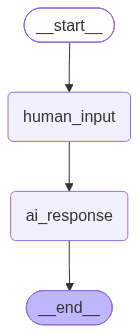

In [8]:
from IPython.display import display, Markdown, Image
class ChatState(TypedDict):
    messages: Annotated[list, my_reducer]
    turn: int

graph = builder.compile()
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


Types Of Flows: 
Sequential Flow,
Conditional Flow

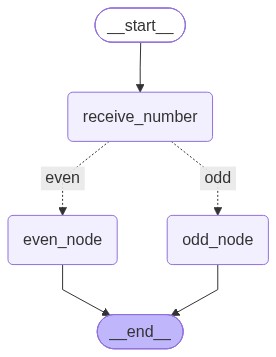

In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

class NumberState(TypedDict):
    value: int
    result: str

def receive_number(state: NumberState) -> NumberState:
    print(f"Received number: {state['value']}")
    return{}

def check_even_odd(state: NumberState) -> Literal["even", "odd"]:
    if state["value"] % 2 == 0:
        return "even"
    else:
        return "odd"

def even_node(state: NumberState) -> NumberState:
    msg = f"{state['value']} is even."
    print(f"{even_node} msg")
    return {"result": msg}

def odd_node(state: NumberState) -> NumberState:
    msg = f"{state['value']} is odd."
    print(f"{odd_node} msg")
    return {"result": msg}


builder = StateGraph(NumberState)
builder.add_node("receive_number", receive_number)
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)

builder.add_edge(START, "receive_number")

builder.add_conditional_edges(
    "receive_number", check_even_odd, {
    "even": "even_node",
    "odd": "odd_node"
}   
)

builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)






Dynamcic Routing

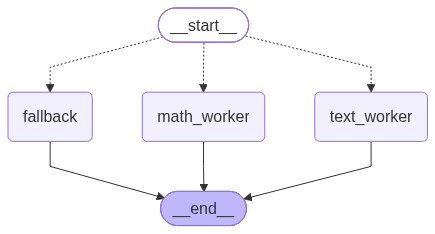

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

#state definition
class TaskState(TypedDict):
    task_type: str
    input_data: str
    output_data: str

def dispatch(state: TaskState) -> Literal["math_worker", "text_worker", "fallback"]:
    #choose worker based on task type
    task = state["task_type"].lower().strip()
    if task == "math":
        return "math_worker"
    elif task == "text":
        return "text_worker"
    else:
        return "fallback"

def math_worker(state: TaskState) -> TaskState:
    #perform math operation
    try:
        result = str(eval(state["input_data"]))
    except Exception:
        result = "Error in math operation"
    print(f" [math_worker] Input: {state['input_data']}, Output: {result}")
    return {"output_data": result}

def text_worker(state: TaskState) -> TaskState:
    #perform text operation (e.g., reverse string)
    result = state["input_data"][::-1]
    print(f" [text_worker] Input: {state['input_data']}, Output: {result}")
    return {"output_data": result}  

def fallback(state: TaskState) -> TaskState:
    #handle unknown task types
    result = "Unknown task type"
    print(f" [fallback] Input: {state['input_data']}, Output: {result}")
    return {"output_data": result}

builder = StateGraph(TaskState)
builder.add_node("math_worker", math_worker)
builder.add_node("text_worker", text_worker)
builder.add_node("fallback", fallback)

builder.add_conditional_edges(
    START, dispatch, {
        "math_worker": "math_worker",
        "text_worker": "text_worker",
        "fallback": "fallback"
    }
)

builder.add_edge("math_worker", END)
builder.add_edge("text_worker", END)    
builder.add_edge("fallback", END)

graph = builder.compile()

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)



In [3]:
task_inputs = [
    {"task_type": "math", "input_data": "5 + 3", "output_data": ""},
    {"task_type": "text", "input_data": "Hello, World!", "output_data": ""},
    {"task_type": "unknown", "input_data": "Some data", "output_data": ""}
]

for task_input in task_inputs:
    result = graph.invoke(task_input)
    print(f"Final Result for task '{task_input['task_type']}': {result['output_data']}")

 [math_worker] Input: 5 + 3, Output: 8
Final Result for task 'math': 8
 [text_worker] Input: Hello, World!, Output: !dlroW ,olleH
Final Result for task 'text': !dlroW ,olleH
 [fallback] Input: Some data, Output: Unknown task type
Final Result for task 'unknown': Unknown task type


Tool Calling - built using langchain in langgraph

In [19]:
import os
import getpass
from langchain_groq import ChatGroq

# 1. Securely request your free key if not already cached in your environment
if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Paste your free Groq API Key (gsk_...): ")

# 2. Instantiate using a supported free-tier production model
# Good options: "openai/gpt-oss-120b" (Strong reasoning) or "qwen/qwen3.6-27b" (Vision/Multimodal)
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.6,
    max_tokens=500
)

# 3. Invoke the model
try:
    print("\nSending free tier test request...")
    response = llm.invoke("Give me an encouraging 1-sentence thought about coding.")
    print("\n[Groq Response]:")
    print(response.content)
except Exception as e:
    print(f"\nAn error occurred: {e}")
    print("Tip: If you hit a 404, verify active models at: https://console.groq.com/docs/models")



Sending free tier test request...

[Groq Response]:
Every line of code you write is a step closer to turning your ideas into reality.


In [20]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def add(a: int, b: int) -> int:
    """Arithmetic: Adds two integers."""
    return a + b

@tool
def get_weather(city: str) -> str:
    """Weather: Returns the current weather for a given city."""
    # Placeholder implementation; in a real scenario, you'd call a weather API
    return f"The current weather in {city} is sunny with a temperature of 25°C."

Tool Calling Loop

In [21]:

tools = [add, get_weather]

llm_with_tools = llm.bind_tools(tools)

test = HumanMessage(content="What's the weather in New York?")

try:
    response = llm_with_tools.invoke([test]) # Pass within a message list
    print("\n--- Model Response Output ---")
    print("Raw Content:", response.content)
    print("Tools Called:", response.tool_calls)
except Exception as e:
    print(f"\nExecution failed: {e}")




--- Model Response Output ---
Raw Content: 
Tools Called: [{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'fc_71d71d7e-d60c-4513-a1c3-03ff98da36eb', 'type': 'tool_call'}]


Connecting Tools TO Langgraph

Graph successfully compiled!


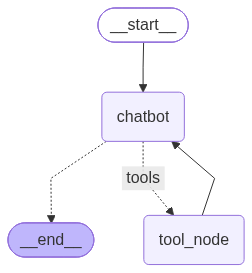

In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState
from IPython.display import display, Image

# 1. Bind tools to your working free tier model
tools = [add, get_weather]
llm_with_tools = llm.bind_tools(tools)

# 2. Define your agent node
def chatbot(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# 3. Instantiate the Tool Execution Node
tool_node = ToolNode(tools)

# 4. Construct the Graph Workflow
builder = StateGraph(MessagesState)

# Register the nodes with explicit names
builder.add_node("chatbot", chatbot)
builder.add_node("tool_node", tool_node)  # <-- Registered as 'tool_node'

# Connect the entry point
builder.add_edge(START, "chatbot")

# FIX 1: Map the conditional edge to point to 'tool_node' instead of default 'tools'
builder.add_conditional_edges(
    "chatbot", 
    tools_condition, 
    {"tools": "tool_node", END: END}
)

# FIX 2: Route the execution path back to 'chatbot' from 'tool_node'
builder.add_edge("tool_node", "chatbot")

# 5. Compile safely without validation errors
graph = builder.compile()
print("Graph successfully compiled!")

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


AI AGENT USING LANGGRAPH

In [4]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image
from langchain_core.tools import tool

# 1. Import the updated constructor here
from langchain.agents import create_agent

@tool
def multiply(a: int, b: int) -> int:
    """Arithmetic: Multiplies two integers."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Arithmetic: Adds two integers."""
    return a + b

llm = ChatGroq(
    model="openai/gpt-oss-20b",  # Replace with your intended valid Groq model identifier
)

tools = [multiply, add]

# 2. Use create_agent instead of create_react_agent
# 3. Use 'system_prompt' if you need to provide instructions
agent = create_agent(
    model=llm, 
    tools=tools,
    system_prompt="You are a helpful assistant." 
)




In [6]:
from langchain_core.messages import HumanMessage

# Ensure you have updated the model string to a valid Groq model name prior to running this!
response = agent.invoke({"messages": [HumanMessage(content="Please multiply 6 by 7 and then add 10 to the result.")]})
print("\n--- Agent Response Output ---")

print("="*60)
for msg in response["messages"]:
    role = msg.__class__.__name__
    
    # 1. Safely check for tool calls using dictionary syntax
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"{role} (Tool Calls):")
        for tool_call in msg.tool_calls:
            # Dictionaries use keys: 'name' and 'args'
            print(f" -> Will invoke tool: {tool_call['name']}, input args: {tool_call['args']}")
            
    # 2. Capture the actual outputs when the ToolMessage role appears
    elif role == "ToolMessage":
        print(f"{role}: Execution Result -> {msg.content}")
        
    else:
        print(f"{role}: {msg.content}")
print("="*60)



--- Agent Response Output ---
HumanMessage: Please multiply 6 by 7 and then add 10 to the result.
AIMessage (Tool Calls):
 -> Will invoke tool: multiply, input args: {'a': 6, 'b': 7}
ToolMessage: Execution Result -> 42
AIMessage (Tool Calls):
 -> Will invoke tool: add, input args: {'a': 42, 'b': 10}
ToolMessage: Execution Result -> 52
AIMessage: 6 × 7 = 42, and 42 + 10 = **52**.


Memory in langgraph
methods: checkpoint

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

class CounterState(TypedDict):
    count: int
    messages: list

def increment(state: CounterState) -> CounterState:
    new_count = state["count"] + 1
    new_message = f"Count incremented to {new_count}"
    print(new_message)
    return {"count": new_count, "messages": state["messages"] + [new_message]}

builder = StateGraph(CounterState)
builder.add_node("increment", increment)
builder.add_edge(START, "increment")
builder.add_edge("increment", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)




HITL- HUMAN IN THE LOOP

In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

# Define graph state
class SimpleState(TypedDict):
    proposed_action: str
    approved: bool
    result: str

# Define node actions
def propose_action(state: SimpleState) -> dict:
    action = "Send a welcome email to the new user."
    print(f"Proposed Action: {action}")
    return {"proposed_action": action}

def ask_human(state: SimpleState) -> dict:
    print(f"Asking for human approval for action: {state['proposed_action']}")
    
    # The graph pauses execution right here
    answer = interrupt("Do you approve this action? (yes/no) hint: type 'yes' or 'no'")

    approved = (str(answer).strip().lower() == "yes")
    print(f"Human Approval: {'Approved' if approved else 'Denied'}")
    return {"approved": approved}

def execute_action(state: SimpleState) -> dict:
    if state["approved"]:
        result = f"Action executed: {state['proposed_action']}"
    else:
        result = "Action was not approved and therefore not executed."
    print(result)
    return {"result": result}

# Build graph blueprint
builder = StateGraph(SimpleState)
builder.add_node("propose_action", propose_action)
builder.add_node("ask_human", ask_human)
builder.add_node("execute_action", execute_action)

builder.add_edge(START, "propose_action")
builder.add_edge("propose_action", "ask_human")
builder.add_edge("ask_human", "execute_action")
builder.add_edge("execute_action", END)

# Compile with checkpointing memory
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Fixed configuration dict separation
config = {
    "configurable": {
        "thread_id": "thread_1"
    },
    "metadata": {
        "user_id": "user_123", 
        "session_id": "session_456"
    }
}

# --- 1. First Execution: Proposes and halts at human prompt ---
print("--- STARTING WORKFLOW ---")
initial_result = graph.invoke(
    {"proposed_action": "", "approved": False, "result": ""}, 
    config=config
)

# --- 2. Second Execution: Simulating the human inputting "yes" ---
print("\n--- RESUMING WITH HUMAN APPROVAL ---")
final_result = graph.invoke(
    Command(resume="yes"), 
    config=config
)

print("\n--- WORKFLOW FINISHED ---")
print("Final State Dictionary Summary:", final_result)







    

--- STARTING WORKFLOW ---
Proposed Action: Send a welcome email to the new user.
Asking for human approval for action: Send a welcome email to the new user.

--- RESUMING WITH HUMAN APPROVAL ---
Asking for human approval for action: Send a welcome email to the new user.
Human Approval: Approved
Action executed: Send a welcome email to the new user.

--- WORKFLOW FINISHED ---
Final State Dictionary Summary: {'proposed_action': 'Send a welcome email to the new user.', 'approved': True, 'result': 'Action executed: Send a welcome email to the new user.'}
